In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [3]:
#Load data
df = pd.read_csv('data/airline_flight_delay_data.csv')

In [4]:
print(df.head())

   Flight_ID   Airline  Distance_km  Departure_Delay_min  Arrival_Delay_min  \
0          1    Indigo         7609                    4                155   
1          2  Emirates        11735                  148                 65   
2          3     Delta         3555                  176                 72   
3          4    Indigo         7539                   25                154   
4          5  Emirates        11483                  150                 76   

  Delay_Status  
0      Delayed  
1      Delayed  
2      Delayed  
3       OnTime  
4       OnTime  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Flight_ID            15000 non-null  int64 
 1   Airline              15000 non-null  object
 2   Distance_km          15000 non-null  int64 
 3   Departure_Delay_min  15000 non-null  int64 
 4   Arrival_Delay_min    15000 non-null  int64 
 5   Delay_Status         15000 non-null  object
dtypes: int64(4), object(2)
memory usage: 703.3+ KB
None


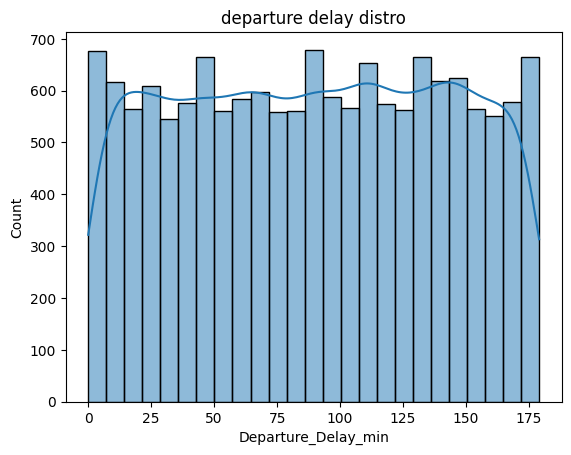

In [9]:
sns.histplot(df['Departure_Delay_min'], kde=True)
plt.title('departure delay distro')
plt.show()

In [16]:
X = df[['Distance_km', 'Arrival_Delay_min']]
y = df['Departure_Delay_min']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model = LinearRegression()

In [19]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
preds = model.predict(X_test)

In [21]:
print('MAE:', mean_absolute_error(y_test, preds))

MAE: 45.87258210382275
